# APPROX-CR: Approximate Cognitive Reserve Index
## Development of ML Algorithm (Gavett et al., 2024)

This notebook implements three models (Minimal, Extended, Full) to predict residual cognitive reserve index (RRI).

In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("="*80)
print("라이브러리 로드 완료")
print("="*80)

라이브러리 로드 완료


In [9]:
# 데이터 로드
df = pd.read_csv('/Users/othree/Cognitive Reserve Modeling/Data/ADNI_final_preprocessed.csv')

print("="*80)
print("데이터 로드 완료")
print("="*80)
print(f"전체 행 수: {df.shape[0]:,}")
print(f"전체 열 수: {df.shape[1]:,}")
print(f"\n컬럼 목록:")
print(df.columns.tolist())

데이터 로드 완료
전체 행 수: 879
전체 열 수: 140

컬럼 목록:
['New_Path', 'Image Data ID', 'Subject', 'Group-RS:InitialDX', 'Sex', 'Age', 'Visit', 'Description', 'Acq Date', 'RS:DX_fill', 'DX2', 'RID', 'COLPROT', 'ORIGPROT', 'PTID', 'SITE', 'VISCODE', 'EXAMDATE', 'DX_bl', 'AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'PTMARRY', 'APOE4', 'FDG', 'PIB', 'AV45', 'FBB', 'ABETA', 'TAU', 'PTAU', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'DIGITSCOR', 'TRABSCOR', 'FAQ', 'MOCA', 'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan', 'EcogPtOrgan', 'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang', 'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt', 'EcogSPTotal', 'FLDSTRENG', 'FSVERSION', 'IMAGEUID', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'DX', 'mPACCdigit', 'mPACCtrailsB', 'EXAMDATE_bl', 'CDRSB_bl', 'ADAS11_bl', 'ADAS13_bl', 'ADASQ4_bl', '

In [10]:
# Feature sets 정의
minimal_features = [
    'AGE',
    'PTEDUCAT',
    'male'
]

extended_features = [
    'AGE',
    'PTEDUCAT',
    'male',
    'MMSE_bl'
]

full_features = [
    'AGE',
    'PTEDUCAT',
    'male',
    'MMSE_bl',
    'CDRSB',
    'EcogSPTotal',
    'EcogSPMem'
]

print("="*80)
print("Feature Sets 정의")
print("="*80)
print(f"\nMinimal features ({len(minimal_features)}): {minimal_features}")
print(f"\nExtended features ({len(extended_features)}): {extended_features}")
print(f"\nFull features ({len(full_features)}): {full_features}")

Feature Sets 정의

Minimal features (3): ['AGE', 'PTEDUCAT', 'male']

Extended features (4): ['AGE', 'PTEDUCAT', 'male', 'MMSE_bl']

Full features (7): ['AGE', 'PTEDUCAT', 'male', 'MMSE_bl', 'CDRSB', 'EcogSPTotal', 'EcogSPMem']


In [11]:
# 원본 데이터에 RRI 병합
# df_rri의 인덱스를 사용하여 원본 df에 RRI 추가

# 각 모델에 필요한 feature가 모두 있는지 확인
all_features = list(set(minimal_features + extended_features + full_features))

missing_features = [f for f in all_features if f not in df.columns]
if missing_features:
    print("="*80)
    print("경고: 다음 features가 데이터에 없습니다:")
    print(missing_features)
    print("="*80)
else:
    print("="*80)
    print("모든 features가 데이터에 존재합니다.")
    print("="*80)

# 각 feature set에 대해 결측치 없는 데이터 생성
df_minimal = df[minimal_features + ['cr']].dropna()
df_extended = df[extended_features + ['cr']].dropna()
df_full = df[full_features + ['cr']].dropna()

print(f"\nMinimal model - 샘플 수: {len(df_minimal):,}")
print(f"Extended model - 샘플 수: {len(df_extended):,}")
print(f"Full model - 샘플 수: {len(df_full):,}")

모든 features가 데이터에 존재합니다.

Minimal model - 샘플 수: 879
Extended model - 샘플 수: 879
Full model - 샘플 수: 296


## Step 3: Bayesian Optimization with XGBoost

각 모델에 대해 Bayesian Optimization으로 hyperparameter tuning 수행  
- 10-fold cross-validation
- 200번 시도 (최대)
- Early stopping: 100회 개선 없으면 중단

In [12]:
# Hyperparameter search space 정의
param_space = {
    'n_estimators': Integer(50, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'min_child_weight': Integer(1, 10),
    'gamma': Real(0.0, 0.5),
    'reg_alpha': Real(0.0, 1.0),
    'reg_lambda': Real(0.0, 1.0)
}

print("="*80)
print("Hyperparameter Search Space")
print("="*80)
for param, space in param_space.items():
    print(f"  {param}: {space}")

Hyperparameter Search Space
  n_estimators: Integer(low=50, high=500, prior='uniform', transform='identity')
  max_depth: Integer(low=3, high=10, prior='uniform', transform='identity')
  learning_rate: Real(low=0.01, high=0.3, prior='log-uniform', transform='identity')
  subsample: Real(low=0.5, high=1.0, prior='uniform', transform='identity')
  colsample_bytree: Real(low=0.5, high=1.0, prior='uniform', transform='identity')
  min_child_weight: Integer(low=1, high=10, prior='uniform', transform='identity')
  gamma: Real(low=0.0, high=0.5, prior='uniform', transform='identity')
  reg_alpha: Real(low=0.0, high=1.0, prior='uniform', transform='identity')
  reg_lambda: Real(low=0.0, high=1.0, prior='uniform', transform='identity')


In [13]:
# Bayesian Optimization 함수 정의
def bayesian_optimization_xgb(X, y, param_space, model_name, n_iter=200, cv=10):
    """
    Bayesian Optimization으로 XGBoost hyperparameter tuning
    
    Parameters:
    -----------
    X : array-like
        Feature matrix
    y : array-like
        Target variable
    param_space : dict
        Hyperparameter search space
    model_name : str
        Model name for printing
    n_iter : int
        Maximum number of iterations (default: 200)
    cv : int
        Number of cross-validation folds (default: 10)
    
    Returns:
    --------
    best_model : XGBRegressor
        Best model with optimized hyperparameters
    best_params : dict
        Best hyperparameters
    cv_results : dict
        Cross-validation results
    """
    
    print("="*80)
    print(f"Starting Bayesian Optimization for {model_name}")
    print("="*80)
    print(f"Total samples: {len(X):,}")
    print(f"Features: {X.shape[1]}")
    print(f"CV folds: {cv}")
    print(f"Max iterations: {n_iter}")
    print()
    
    # Base estimator
    base_estimator = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    
    # BayesSearchCV
    opt = BayesSearchCV(
        estimator=base_estimator,
        search_spaces=param_space,
        n_iter=n_iter,
        cv=cv,
        n_jobs=-1,
        scoring='neg_mean_squared_error',
        random_state=42,
        verbose=1
    )
    
    # Fit
    opt.fit(X, y)
    
    print("\n" + "="*80)
    print(f"Optimization Complete for {model_name}")
    print("="*80)
    print(f"Best CV Score (MSE): {-opt.best_score_:.4f}")
    print(f"Best CV Score (RMSE): {np.sqrt(-opt.best_score_):.4f}")
    print(f"\nBest Parameters:")
    for param, value in opt.best_params_.items():
        print(f"  {param}: {value}")
    
    return opt.best_estimator_, opt.best_params_, opt.cv_results_

print("Bayesian Optimization 함수 정의 완료")

Bayesian Optimization 함수 정의 완료


### 3.1 Minimal Model

In [14]:
# Minimal Model 학습
X_minimal = df_minimal[minimal_features]
y_minimal = df_minimal['cr']

best_model_minimal, best_params_minimal, cv_results_minimal = bayesian_optimization_xgb(
    X_minimal, y_minimal, param_space, "Minimal Model", n_iter=200, cv=10
)

Starting Bayesian Optimization for Minimal Model
Total samples: 879
Features: 3
CV folds: 10
Max iterations: 200

Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 c

### 3.2 Extended Model

In [15]:
# Extended Model 학습
X_extended = df_extended[extended_features]
y_extended = df_extended['cr']

best_model_extended, best_params_extended, cv_results_extended = bayesian_optimization_xgb(
    X_extended, y_extended, param_space, "Extended Model", n_iter=200, cv=10
)

Starting Bayesian Optimization for Extended Model
Total samples: 879
Features: 4
CV folds: 10
Max iterations: 200

Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 

### 3.3 Full Model

In [16]:
# Full Model 학습
X_full = df_full[full_features]
y_full = df_full['cr']

best_model_full, best_params_full, cv_results_full = bayesian_optimization_xgb(
    X_full, y_full, param_space, "Full Model", n_iter=200, cv=10
)

Starting Bayesian Optimization for Full Model
Total samples: 296
Features: 7
CV folds: 10
Max iterations: 200

Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 candidates, totalling 10 fits
Fitting 10 folds for each of 1 cand

## Step 4: Model Evaluation & Comparison

In [17]:
# 모델 성능 비교
models = {
    'Minimal': (best_model_minimal, X_minimal, y_minimal),
    'Extended': (best_model_extended, X_extended, y_extended),
    'Full': (best_model_full, X_full, y_full)
}

results = []

for model_name, (model, X, y) in models.items():
    # 10-fold CV로 최종 평가
    cv_scores = cross_val_score(
        model, X, y, cv=10, scoring='neg_mean_squared_error', n_jobs=-1
    )
    
    mse = -cv_scores.mean()
    rmse = np.sqrt(mse)
    std = cv_scores.std()
    
    # R² score
    r2_scores = cross_val_score(
        model, X, y, cv=10, scoring='r2', n_jobs=-1
    )
    r2 = r2_scores.mean()
    r2_std = r2_scores.std()
    
    results.append({
        'Model': model_name,
        'Features': len(X.columns),
        'Samples': len(X),
        'RMSE': rmse,
        'RMSE_std': np.sqrt(std),
        'R²': r2,
        'R²_std': r2_std
    })

results_df = pd.DataFrame(results)

print("="*80)
print("MODEL COMPARISON (10-Fold CV)")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

MODEL COMPARISON (10-Fold CV)
   Model  Features  Samples     RMSE  RMSE_std       R²   R²_std
 Minimal         3      879 0.705035  0.286632 0.077198 0.047347
Extended         4      879 0.594513  0.270307 0.344821 0.076762
    Full         7      296 0.544513  0.289107 0.528216 0.102205


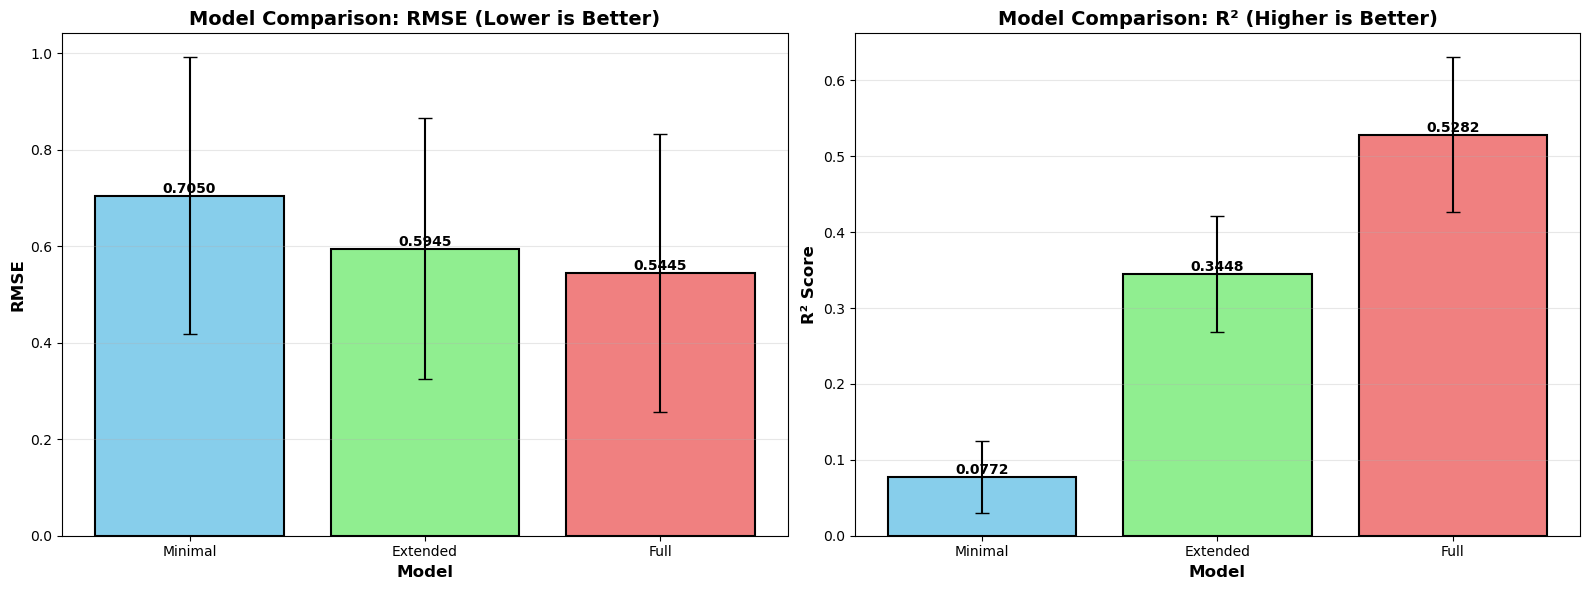

In [18]:
# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE 비교
ax1 = axes[0]
x_pos = np.arange(len(results_df))
bars1 = ax1.bar(x_pos, results_df['RMSE'], yerr=results_df['RMSE_std'],
                color=['skyblue', 'lightgreen', 'lightcoral'],
                edgecolor='black', linewidth=1.5, capsize=5)

ax1.set_xlabel('Model', fontweight='bold', fontsize=12)
ax1.set_ylabel('RMSE', fontweight='bold', fontsize=12)
ax1.set_title('Model Comparison: RMSE (Lower is Better)', fontweight='bold', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['Model'])
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontweight='bold')

# R² 비교
ax2 = axes[1]
bars2 = ax2.bar(x_pos, results_df['R²'], yerr=results_df['R²_std'],
                color=['skyblue', 'lightgreen', 'lightcoral'],
                edgecolor='black', linewidth=1.5, capsize=5)

ax2.set_xlabel('Model', fontweight='bold', fontsize=12)
ax2.set_ylabel('R² Score', fontweight='bold', fontsize=12)
ax2.set_title('Model Comparison: R² (Higher is Better)', fontweight='bold', fontsize=14)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df['Model'])
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Step 5: Feature Importance

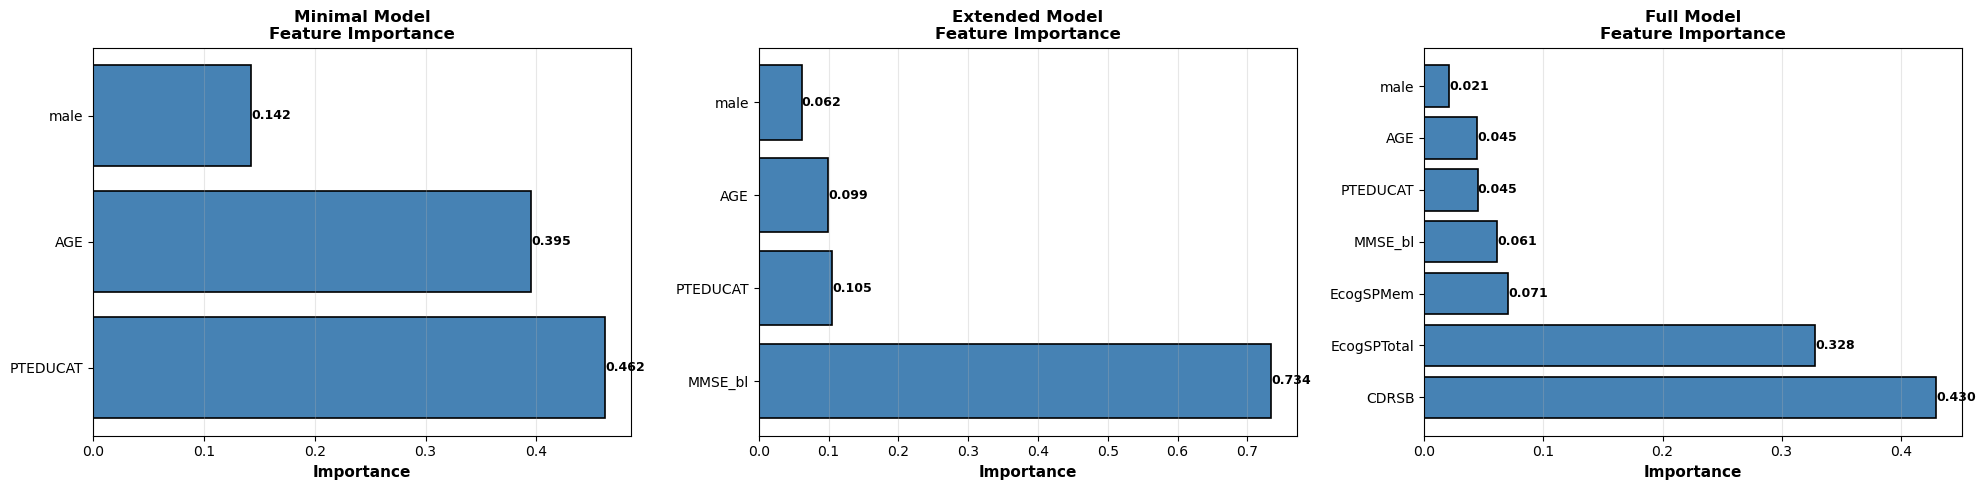

In [19]:
# Feature importance 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

model_data = [
    ('Minimal', best_model_minimal, minimal_features),
    ('Extended', best_model_extended, extended_features),
    ('Full', best_model_full, full_features)
]

for idx, (model_name, model, features) in enumerate(model_data):
    ax = axes[idx]
    
    # Feature importance
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': features,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    # Plot
    bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'],
                   color='steelblue', edgecolor='black', linewidth=1.2)
    
    ax.set_xlabel('Importance', fontweight='bold', fontsize=11)
    ax.set_title(f'{model_name} Model\nFeature Importance', fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
               f'{width:.3f}',
               ha='left', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## Step 6: Generate APPROX-CR Predictions

In [20]:
# 각 모델로 APPROX-CR 예측
df_minimal['APPROX_CR_minimal'] = best_model_minimal.predict(X_minimal)
df_extended['APPROX_CR_extended'] = best_model_extended.predict(X_extended)
df_full['APPROX_CR_full'] = best_model_full.predict(X_full)

print("="*80)
print("APPROX-CR 예측 완료")
print("="*80)
print("\nAPPROX-CR (Minimal) 통계:")
print(df_minimal['APPROX_CR_minimal'].describe())
print("\nAPPROX-CR (Extended) 통계:")
print(df_extended['APPROX_CR_extended'].describe())
print("\nAPPROX-CR (Full) 통계:")
print(df_full['APPROX_CR_full'].describe())

APPROX-CR 예측 완료

APPROX-CR (Minimal) 통계:
count    879.000000
mean      -0.000051
std        0.215740
min       -0.723523
25%       -0.137763
50%        0.047900
75%        0.158578
max        0.361275
Name: APPROX_CR_minimal, dtype: float64

APPROX-CR (Extended) 통계:
count    879.000000
mean       0.000455
std        0.437260
min       -1.190223
25%       -0.392433
50%        0.036195
75%        0.388456
max        0.802021
Name: APPROX_CR_extended, dtype: float64

APPROX-CR (Full) 통계:
count    296.000000
mean      -0.059660
std        0.598939
min       -2.154022
25%       -0.638697
50%        0.125610
75%        0.437209
max        1.126702
Name: APPROX_CR_full, dtype: float64


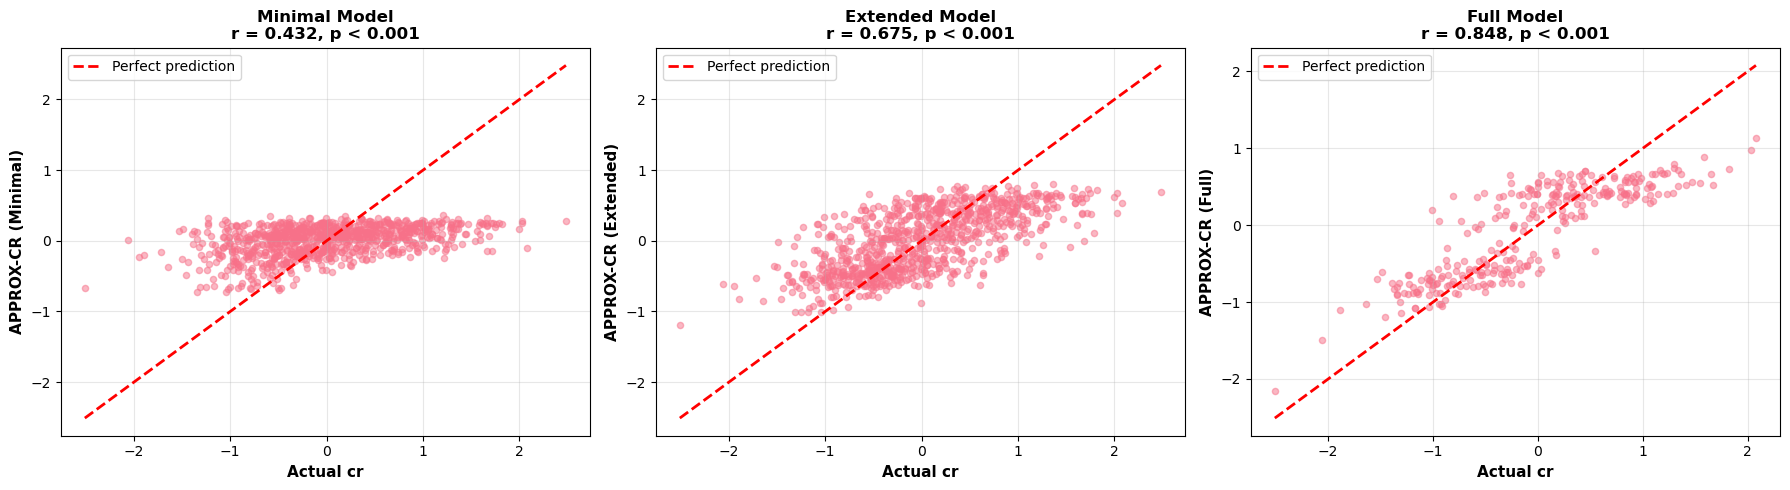

In [21]:
# APPROX-CR vs RRI 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_pred = [
    ('Minimal', df_minimal, 'APPROX_CR_minimal'),
    ('Extended', df_extended, 'APPROX_CR_extended'),
    ('Full', df_full, 'APPROX_CR_full')
]

for idx, (model_name, data, approx_col) in enumerate(models_pred):
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(data['cr'], data[approx_col], alpha=0.5, s=20)
    
    # Perfect prediction line
    min_val = min(data['cr'].min(), data[approx_col].min())
    max_val = max(data['cr'].max(), data[approx_col].max())
    ax.plot([min_val, max_val], [min_val, max_val], 
           'r--', linewidth=2, label='Perfect prediction')
    
    # R² 계산
    from scipy.stats import pearsonr
    r, p = pearsonr(data['cr'], data[approx_col])
    
    ax.set_xlabel('Actual cr', fontweight='bold', fontsize=11)
    ax.set_ylabel(f'APPROX-CR ({model_name})', fontweight='bold', fontsize=11)
    ax.set_title(f'{model_name} Model\nr = {r:.3f}, p < 0.001', 
                fontweight='bold', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Save Results

In [22]:
# 결과 저장
import pickle

# 모델 저장
models_to_save = {
    'minimal': best_model_minimal,
    'extended': best_model_extended,
    'full': best_model_full
}

for model_name, model in models_to_save.items():
    model_path = f'/Users/othree/Cognitive Reserve Modeling/Code/approx_cr_{model_name}_model.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved {model_name} model to {model_path}")

# 결과 DataFrame 저장
results_df.to_csv('/Users/othree/Cognitive Reserve Modeling/Code/approx_cr_model_comparison.csv', 
                  index=False)
print("\nSaved model comparison results to approx_cr_model_comparison.csv")

print("\n" + "="*80)
print("모든 결과 저장 완료!")
print("="*80)

Saved minimal model to /Users/othree/Cognitive Reserve Modeling/Code/approx_cr_minimal_model.pkl
Saved extended model to /Users/othree/Cognitive Reserve Modeling/Code/approx_cr_extended_model.pkl
Saved full model to /Users/othree/Cognitive Reserve Modeling/Code/approx_cr_full_model.pkl

Saved model comparison results to approx_cr_model_comparison.csv

모든 결과 저장 완료!


Exception ignored in: <function ResourceTracker.__del__ at 0x10554dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103895bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10731dbc0>
Traceback (most recent call last